In [1]:
from __future__ import print_function, division
import os
import numpy as np
import math
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import matplotlib.cm as cm
%matplotlib inline

# --------------------------------------------------
# DIRECTORIES
# --------------------------------------------------
SIM_DIR = "/home/hp/raytrace_work/raytrace_results/Simulation_Data_201x201"
OUT_DIR = "/home/hp/raytrace_work/raytrace_results/Critical_Surface"

if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)

# --------------------------------------------------
# LOAD PARAMETERS
# --------------------------------------------------
params    = np.load(os.path.join(SIM_DIR, "sim_params.npy"),
                    allow_pickle=True).item()
freq_list = np.array(params['freq_list'])
ny        = int(params['ny'])
nx        = int(params['nx'])
rect      = params['rect']
rsph      = params['rsph']
subset_A  = params['subset_A']   # 25 ray global indices

def mhz_int(f):
    return int(round(f / 1.e6))

# --------------------------------------------------
# PHYSICAL Y,Z COORDINATES
# --------------------------------------------------
y_arr = np.linspace(rect[0], rect[2], nx)
z_arr = np.linspace(rect[1], rect[3], ny)

In [2]:
# --------------------------------------------------
# PARAMS OBJECT
# --------------------------------------------------
class Params(object):
    pass

prm          = Params()
prm.r_chromo = 1.02
prm.r_corona = 1.05

# --------------------------------------------------
# ELECTRON DENSITY MODEL
# --------------------------------------------------
def density_only(prm, x, y, z):
    r2 = x*x + y*y + z*z
    r  = math.sqrt(r2)

    global r_corm16, r_corm6, r_corm2d5

    R0 = 6.955e5
    g1 = 3.09e8
    g2 = 1.58e8
    g3 = 2.51e6

    r_corm16  = prm.r_corona**(-16)
    r_corm6   = prm.r_corona**(-6)
    r_corm2d5 = prm.r_corona**(-2.5)

    A = np.zeros((4, 4))
    A[0] = [1., prm.r_chromo, prm.r_chromo**2,
            prm.r_chromo**3]
    A[1] = [1., prm.r_corona, prm.r_corona**2,
            prm.r_corona**3]
    A[2] = [0., 1., 2.*prm.r_chromo,
            3.*prm.r_chromo**2]
    A[3] = [0., 1., 2.*prm.r_corona,
            3.*prm.r_corona**2]
    A = np.linalg.inv(A)

    rhsa    = np.zeros(4)
    rhsa[0] = 5.7e11 * math.exp(
        -7.7e-4*(R0*(prm.r_chromo - 1) - 500))
    a       = np.dot(A, rhsa)

    if r < prm.r_chromo:
        Ne = 5.7e11 * math.exp(
            -7.7e-4*(R0*(r - 1) - 500))
    else:
        rm2d5     = r**(-2.5)
        rm6       = r**(-6)
        rm16      = r**(-16)
        cosTh     = abs(z / r)
        sqrtCosTh = math.sqrt(cosTh)
        t1 = 1.0 - 0.5*cosTh
        t2 = 1.0 - 0.95*cosTh
        t3 = 1.0 - sqrtCosTh

        if r < prm.r_corona:
            saito_rcor = (g1*r_corm16*t1 +
                          g2*r_corm6*t2  +
                          g3*r_corm2d5*t3)
            rhsb    = np.zeros(4)
            rhsb[1] = 1.
            rhsb[2] = (-438.9e6 * R0 *
                       math.exp(-7.7e-4*(
                           R0*(prm.r_chromo-1)-500))
                       / saito_rcor)
            rhsb[3] = ((-16.*g1*(prm.r_corona**(-17))*t1
                        - 6.*g2*(prm.r_corona**(-7))*t2
                        - 2.5*g3*(prm.r_corona**(-3.5))*t3)
                       / saito_rcor)
            b_coeff = np.dot(A, rhsb)
            Ne = ((a[0] + r*(a[1] + r*(a[2] + r*a[3])))
                  + (b_coeff[0] + r*(b_coeff[1] +
                     r*(b_coeff[2] + r*b_coeff[3])))
                  * saito_rcor)
        else:
            Ne = g1*rm16*t1 + g2*rm6*t2 + g3*rm2d5*t3

    return Ne

In [3]:
# --------------------------------------------------
# CRITICAL ELECTRON DENSITY FOR 15 MHz
# --------------------------------------------------
me    = 9.10938e-28
e_cgs = 4.80326e-10
pi    = math.pi

freq_15 = freq_list[0]
mhz_15  = mhz_int(freq_15)
omega   = 2.0 * pi * freq_15
Ne_cr   = (me * omega**2) / (4.0 * pi * e_cgs**2)

print("Frequency : {} MHz".format(mhz_15))
print("Ne_cr     : {:.6e} cm^-3".format(Ne_cr))

Frequency : 15 MHz
Ne_cr     : 2.790930e+06 cm^-3


In [4]:
# ==================================================
# x search: from outer sphere inward to 0
# Y=0 fixed, vary Z
# For each Z value, vary x inward to find x_crit
# R_crit = sqrt(x_crit^2 + 0^2 + Z^2)
# ==================================================

x_start  = 20.0
x_end    = 0.0
n_steps  = 1000   # fine step size for accuracy

x_arr = np.linspace(x_start, x_end, n_steps)
Y_fixed    = 0.0
z_vals     = z_arr         # 100 Z values
R_crit_z   = np.full(len(z_vals), np.nan)
x_crit_arr  = np.full(len(z_vals), np.nan)


for j in range(len(z_vals)):
    Zj       = z_arr[j]

    Ne_prev = density_only(prm, x_arr[0], Y_fixed, Zj)

    for k in range(1, len(x_arr)):
        x  = x_arr[k]
        Ne = density_only(prm, x, Y_fixed, Zj)

        if Ne >= Ne_cr:
            # interpolate between x_arr[k-1] and x_arr[k]
            x_prev = x_arr[k-1]
            frac   = (Ne_cr - Ne_prev) / (Ne - Ne_prev + 1e-30)
            x_crit = x_prev + frac * (x - x_prev)

            # critical radius
            R_crit_z[j] = math.sqrt(
                x_crit**2 + Y_fixed**2 + Zj**2)
            x_crit_arr[j] = x_crit
            break

        Ne_prev = Ne

    print("  j={:3d}  Z={:7.4f} Rs  "
          "R_crit={}".format(
              j, Zj,
              "{:.8f} Rs".format(R_crit_z[j])
              if not np.isnan(R_crit_z[j])
              else "NOT FOUND"))

valid = ~np.isnan(R_crit_z)
print("\nFound R_crit for {}/{} rays".format(valid.sum(), z_vals))
print("R_crit min = {:.8f} Rs".format(np.nanmin(R_crit_z)))
print("R_crit max = {:.8f} Rs".format(np.nanmax(R_crit_z)))
print("R_crit std = {:.6e} Rs".format(np.nanstd(R_crit_z)))

  j=  0  Z=-2.0000 Rs  R_crit=NOT FOUND
  j=  1  Z=-1.9800 Rs  R_crit=NOT FOUND
  j=  2  Z=-1.9600 Rs  R_crit=NOT FOUND
  j=  3  Z=-1.9400 Rs  R_crit=NOT FOUND
  j=  4  Z=-1.9200 Rs  R_crit=NOT FOUND
  j=  5  Z=-1.9000 Rs  R_crit=NOT FOUND
  j=  6  Z=-1.8800 Rs  R_crit=NOT FOUND
  j=  7  Z=-1.8600 Rs  R_crit=NOT FOUND
  j=  8  Z=-1.8400 Rs  R_crit=NOT FOUND
  j=  9  Z=-1.8200 Rs  R_crit=NOT FOUND
  j= 10  Z=-1.8000 Rs  R_crit=NOT FOUND
  j= 11  Z=-1.7800 Rs  R_crit=NOT FOUND
  j= 12  Z=-1.7600 Rs  R_crit=NOT FOUND
  j= 13  Z=-1.7400 Rs  R_crit=NOT FOUND
  j= 14  Z=-1.7200 Rs  R_crit=NOT FOUND
  j= 15  Z=-1.7000 Rs  R_crit=NOT FOUND
  j= 16  Z=-1.6800 Rs  R_crit=NOT FOUND
  j= 17  Z=-1.6600 Rs  R_crit=NOT FOUND
  j= 18  Z=-1.6400 Rs  R_crit=NOT FOUND
  j= 19  Z=-1.6200 Rs  R_crit=NOT FOUND
  j= 20  Z=-1.6000 Rs  R_crit=NOT FOUND
  j= 21  Z=-1.5800 Rs  R_crit=NOT FOUND
  j= 22  Z=-1.5600 Rs  R_crit=NOT FOUND
  j= 23  Z=-1.5400 Rs  R_crit=NOT FOUND
  j= 24  Z=-1.5200 Rs  R_crit=NOT FOUND


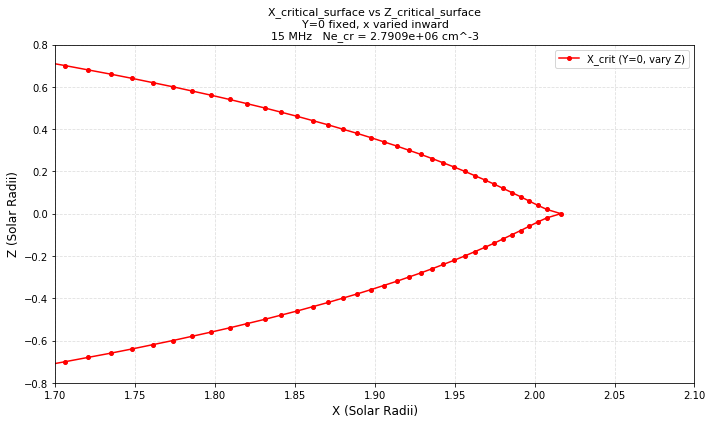


Saved Plot: X_crit vs Z.


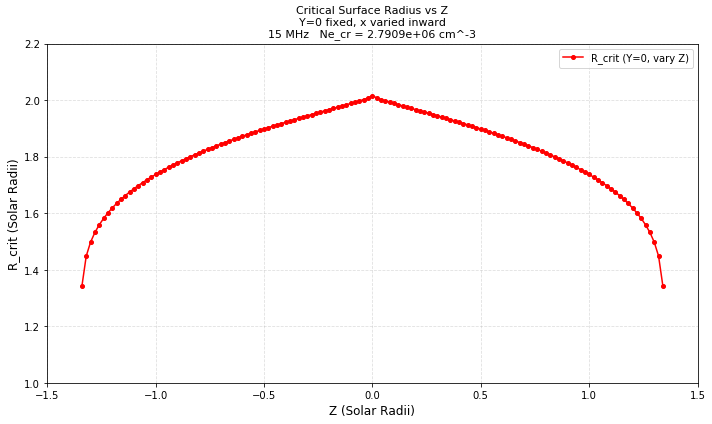


Saved Plot: R_crit vs Z.


In [8]:
# ==================================================
# PLOT 1: X_crit vs Z  (Y=0 fixed)
# ==================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot( x_crit_arr[valid],z_vals[valid],
        linestyle=u'-', marker=u'o',
        markersize=4, linewidth=1.5,
        color=u'red',
        label=u'X_crit (Y=0, vary Z)')

ax.set_xlabel(u'X (Solar Radii)', fontsize=12)
ax.set_ylabel(u'Z (Solar Radii)',
              fontsize=12)
ax.set_title(
    u'X_critical_surface vs Z_critical_surface\n'
    u'Y=0 fixed, x varied inward\n'
    u'15 MHz   Ne_cr = {:.4e} cm^-3'.format(Ne_cr),
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle=u'--', alpha=0.4)
ax.set_xlim(1.7,2.1)
ax.set_ylim(-0.8,0.8)

plt.tight_layout()
plt.savefig(os.path.join(
    OUT_DIR,
    "critical_surface_X_vs_Z_Y0_15mhz.png"), dpi=150)
plt.show()
print("\nSaved Plot: X_crit vs Z.")

 
# ==================================================
# PLOT 2: R_crit vs Z  (Y=0 fixed)
# ==================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot( z_vals[valid], R_crit_z[valid],
        linestyle=u'-', marker=u'o',
        markersize=4, linewidth=1.5,
        color=u'red',
        label=u'R_crit (Y=0, vary Z)')

ax.set_xlabel(u'Z (Solar Radii)', fontsize=12)
ax.set_ylabel(u'R_crit (Solar Radii)',
              fontsize=12)
ax.set_title(
    u'Critical Surface Radius vs Z\n'
    u'Y=0 fixed, x varied inward\n'
    u'15 MHz   Ne_cr = {:.4e} cm^-3'.format(Ne_cr),
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle=u'--', alpha=0.4)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(1,2.2)

plt.tight_layout()
plt.savefig(os.path.join(
    OUT_DIR,
    "critical_surface_R_vs_Z_Y0_15mhz.png"), dpi=150)
plt.show()
print("\nSaved Plot: R_crit vs Z.")

In [10]:
# ==================================================
# x search: from outer sphere inward to 0
# Fixed Z values, vary Y
# For each Y value, vary x inward to find x_crit
# R_crit = sqrt(x_crit^2 + Z^2 + Y^2)
# ==================================================
x_start = 20.0
x_end   = 0.0
n_steps = 1000
x_arr   = np.linspace(x_start, x_end, n_steps)

Z_fixed_arr = np.linspace(0, 1.4, 20)   # 20 Z values
y_vals      = y_arr                     # 100 Y values

# store results: shape (20 Z values, 100 Y values)
R_crit_all = np.full((len(Z_fixed_arr),
                      len(y_vals)), np.nan)

for zi, Zfix in enumerate(Z_fixed_arr):
    print("\nZ_fixed = {:.4f} Rs  "
          "(zi={})".format(Zfix, zi))

    for j in range(len(y_vals)):
        Yj      = y_vals[j]
        Ne_prev = density_only(
            prm, x_arr[0], Yj, Zfix)

        for k in range(1, len(x_arr)):
            x  = x_arr[k]
            Ne = density_only(prm, x, Yj, Zfix)

            if Ne >= Ne_cr:
                x_prev = x_arr[k-1]
                frac   = ((Ne_cr - Ne_prev) /
                          (Ne - Ne_prev + 1e-30))
                x_crit = x_prev + frac*(x - x_prev)

                R_crit_all[zi, j] = math.sqrt(
                    x_crit**2 + Yj**2 + Zfix**2)
                break

            Ne_prev = Ne

        print("  j={:3d}  Y={:7.4f} Rs  R_crit={}".format(
            j, Yj,
            "{:.6f} Rs".format(R_crit_all[zi, j])
            if not np.isnan(R_crit_all[zi, j])
            else "NOT FOUND"))


Z_fixed = 0.0000 Rs  (zi=0)
  j=  0  Y=-2.0000 Rs  R_crit=2.016205 Rs
  j=  1  Y=-1.9800 Rs  R_crit=2.016221 Rs
  j=  2  Y=-1.9600 Rs  R_crit=2.016208 Rs
  j=  3  Y=-1.9400 Rs  R_crit=2.016211 Rs
  j=  4  Y=-1.9200 Rs  R_crit=2.016216 Rs
  j=  5  Y=-1.9000 Rs  R_crit=2.016219 Rs
  j=  6  Y=-1.8800 Rs  R_crit=2.016222 Rs
  j=  7  Y=-1.8600 Rs  R_crit=2.016223 Rs
  j=  8  Y=-1.8400 Rs  R_crit=2.016226 Rs
  j=  9  Y=-1.8200 Rs  R_crit=2.016231 Rs
  j= 10  Y=-1.8000 Rs  R_crit=2.016235 Rs
  j= 11  Y=-1.7800 Rs  R_crit=2.016237 Rs
  j= 12  Y=-1.7600 Rs  R_crit=2.016231 Rs
  j= 13  Y=-1.7400 Rs  R_crit=2.016232 Rs
  j= 14  Y=-1.7200 Rs  R_crit=2.016249 Rs
  j= 15  Y=-1.7000 Rs  R_crit=2.016237 Rs
  j= 16  Y=-1.6800 Rs  R_crit=2.016251 Rs
  j= 17  Y=-1.6600 Rs  R_crit=2.016242 Rs
  j= 18  Y=-1.6400 Rs  R_crit=2.016261 Rs
  j= 19  Y=-1.6200 Rs  R_crit=2.016229 Rs
  j= 20  Y=-1.6000 Rs  R_crit=2.016259 Rs
  j= 21  Y=-1.5800 Rs  R_crit=2.016270 Rs
  j= 22  Y=-1.5600 Rs  R_crit=2.016255 Rs
  j= 

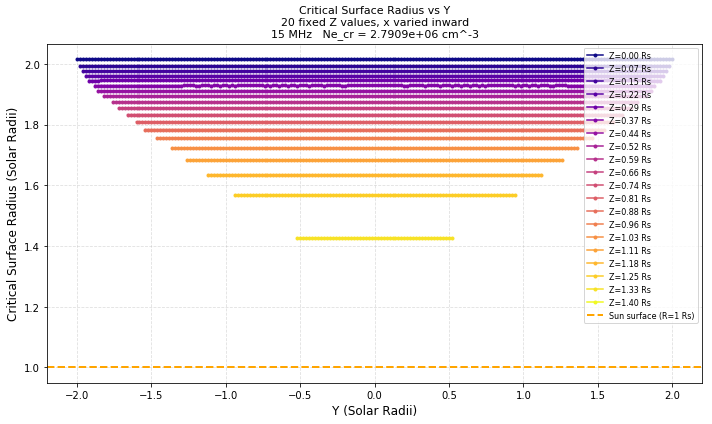


Saved plot.


In [12]:
# ==================================================
# PLOT: R_crit vs Y for all Z values
# ==================================================

colors = cm.plasma(np.linspace(0, 1, len(Z_fixed_arr)))

fig, ax = plt.subplots(figsize=(10, 6))

for zi, Zfix in enumerate(Z_fixed_arr):
    valid_zi = ~np.isnan(R_crit_all[zi, :])
    ax.plot(y_vals[valid_zi],
            R_crit_all[zi, valid_zi],
            linestyle=u'-', marker=u'o',
            markersize=3, linewidth=1.5,
            color=colors[zi],
            label=u'Z={:.2f} Rs'.format(Zfix))

ax.axhline(1.0, color=u'orange',
           linestyle=u'--', linewidth=2.0,
           label=u'Sun surface (R=1 Rs)')

ax.set_xlabel(u'Y (Solar Radii)', fontsize=12)
ax.set_ylabel(u'Critical Surface Radius (Solar Radii)',
              fontsize=12)
ax.set_title(
    u'Critical Surface Radius vs Y\n'
    u'20 fixed Z values, x varied inward\n'
    u'15 MHz   Ne_cr = {:.4e} cm^-3'.format(Ne_cr),
    fontsize=11)
ax.legend(fontsize=8, loc=u'upper right')
ax.grid(True, linestyle=u'--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(
    OUT_DIR,
    "critical_surface_vs_Y_9Zvals_15mhz.png"), dpi=150)
plt.show()
plt.close()
print("\nSaved plot.")

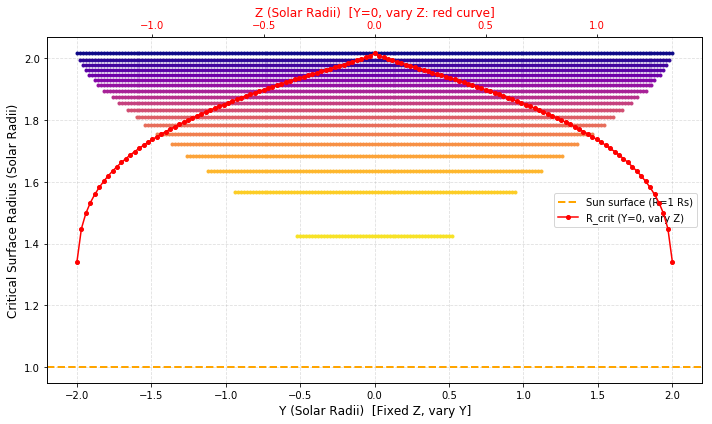

Saved Plot: Combined.


In [13]:
# ==================================================
# COMBINED PLOT: Both on same axes for comparison
# ==================================================
colors = cm.plasma(np.linspace(0, 1, len(Z_fixed_arr)))
fig, ax = plt.subplots(figsize=(10, 6))

# --- Bottom x-axis: Y or Z values for fixed-Z curves (plasma colors) ---
for zi, Zfix in enumerate(Z_fixed_arr):
    valid_zi = ~np.isnan(R_crit_all[zi, :])
    ax.plot(y_vals[valid_zi],
            R_crit_all[zi, valid_zi],
            linestyle=u'-', marker=u'o',
            markersize=3, linewidth=1.5,
            color=colors[zi],
           #label=u'Z={:.2f} Rs'.format(Zfix)
           )

ax.set_xlabel(u'Y (Solar Radii)  [Fixed Z, vary Y]', fontsize=12)
ax.set_ylabel(u'Critical Surface Radius (Solar Radii)', fontsize=12)
ax.grid(True, linestyle=u'--', alpha=0.4)

# --- Top x-axis: Z values for red curve (Y=0, vary Z) ---
ax2 = ax.twiny()
ax2.plot(z_vals[valid], R_crit_z[valid],
         linestyle=u'-', marker=u'o',
         markersize=4, linewidth=1.5,
         color=u'red',
         label=u'R_crit (Y=0, vary Z)')
ax2.set_xlabel(u'Z (Solar Radii)  [Y=0, vary Z: red curve]',
               fontsize=12, color=u'red')
ax2.tick_params(axis=u'x', labelcolor=u'red')

# --- Sun surface reference line (drawn on ax, visible on shared y-axis) ---
ax.axhline(1.0, color=u'orange',
           linestyle=u'--', linewidth=2.0,
           label=u'Sun surface (R=1 Rs)')

# --- Combined legend from both axes ---
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(
    OUT_DIR,
    "critical_surface_Z_&_Y_15mhz.png"), dpi=150)
plt.show()
plt.close()
print("Saved Plot: Combined.")